# Quick start

This notebook is a short illustration of how the `pgam_jax.GAM` class can be fit to data.

## Imports

In [1]:
import jax
import matplotlib.pyplot as plt
import numpy as np
import plotly.graph_objects as go
import seaborn as sns
from matplotlib.patches import Patch

jax.config.update("jax_enable_x64", True)
sns.set_theme(style="whitegrid")

## Generate data

We have 2 input variables:

In [2]:
rng = np.random.default_rng(123)
n_samples = 3000

x1 = rng.uniform(0.0, 1.0, size=n_samples)
x2 = rng.uniform(0.0, 1.0, size=n_samples)

Output data is generated as:

$\mu = \exp\bigl(\mathrm{const} + f_1(x_1) + f_2(x_2)\bigr)$

$y \sim \mathrm{Poisson}(\lambda)$

In [3]:
def smooth_1(x):
    return -0.9 * np.sin(2 * np.pi * x) + 0.7 * np.cos(4 * np.pi * x)


def smooth_2(x):
    return 1.2 * np.exp(-((x - 0.7) ** 2) / 0.02)


def gen_mu(x1, x2):
    return -0.8 + smooth_1(x1) + smooth_2(x2)


mu = gen_mu(x1, x2)
rate = np.exp(mu)
y = rng.poisson(rate)

Plotting $f_1(x_1)$ and $f_2(x_2)$:

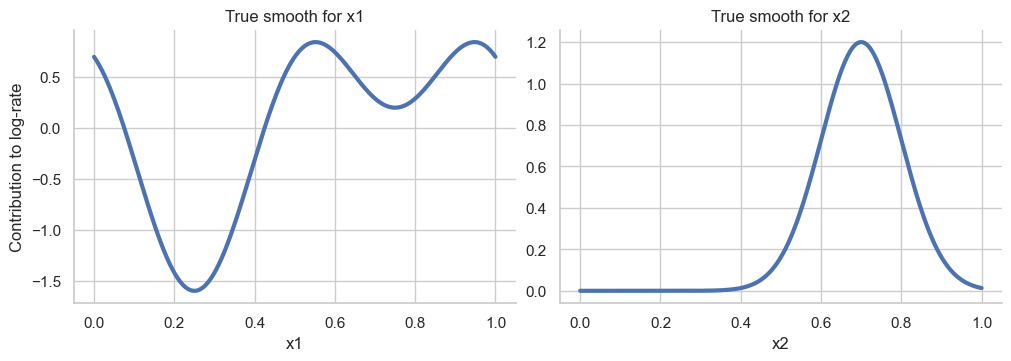

In [4]:
x_plot = np.linspace(0.0, 1.0, 300)

fig, ax = plt.subplots(1, 2, figsize=(10, 3.5), sharex=True, constrained_layout=True)

ax[0].plot(x_plot, smooth_1(x_plot), linewidth=3)
ax[0].set(title="True smooth for x1", xlabel="x1", ylabel="Contribution to log-rate")

ax[1].plot(x_plot, smooth_2(x_plot), linewidth=3)
ax[1].set(title="True smooth for x2", xlabel="x2")

sns.despine()

The rate as a function of both $x_1$ and $x_2$:

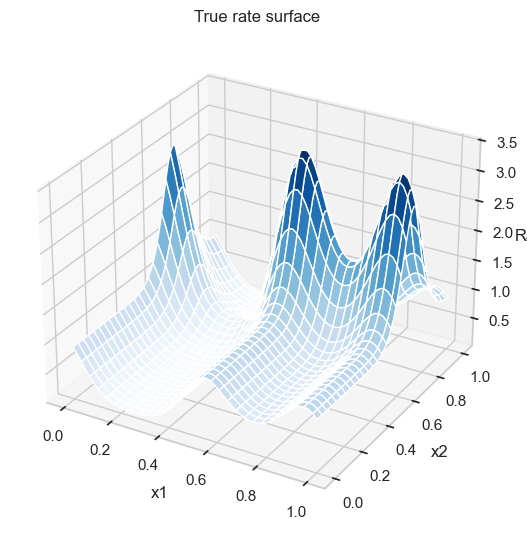

In [5]:
surface_x1 = np.linspace(0.0, 1.0, 60)
surface_x2 = np.linspace(0.0, 1.0, 60)
x1_surface, x2_surface = np.meshgrid(surface_x1, surface_x2)

true_rate_surface = np.exp(gen_mu(x1_surface, x2_surface))

fig = plt.figure(figsize=(7, 5.5))
ax = fig.add_subplot(111, projection="3d")
ax.plot_surface(x1_surface, x2_surface, true_rate_surface, cmap="Blues")
ax.set_title("True rate surface")
ax.set_xlabel("x1")
ax.set_ylabel("x2")
ax.set_zlabel("Rate")
ax.view_init(elev=28, azim=-60)
fig.tight_layout()

The generated spike counts as a function of the inputs:

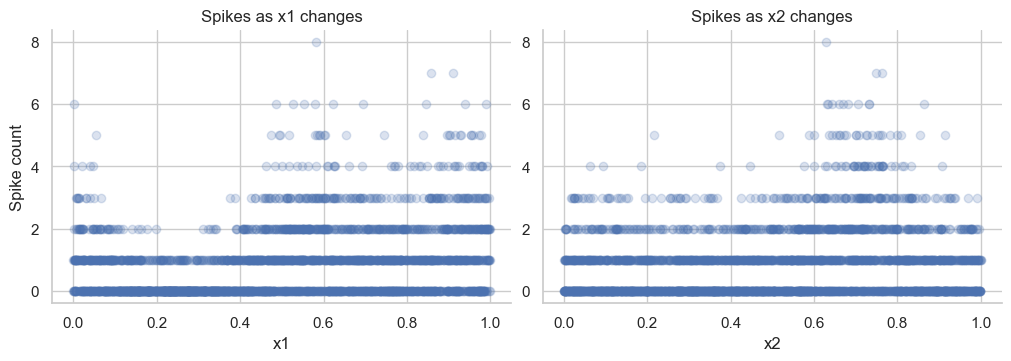

In [6]:
fig, ax = plt.subplots(1, 2, figsize=(10, 3.5), sharex=True, constrained_layout=True)

sort_idx1 = np.argsort(x1)
sort_idx2 = np.argsort(x2)

ax[0].scatter(x1[sort_idx1], y[sort_idx1], alpha=0.2)
ax[1].scatter(x2[sort_idx2], y[sort_idx2], alpha=0.2)

ax[0].set(title="Spikes as x1 changes", xlabel="x1", ylabel="Spike count")
ax[1].set(title="Spikes as x2 changes", xlabel="x2")

sns.despine()

## Fit a GAM to the data

In [7]:
import nemos as nmo

from pgam_jax import GAM

### Create the model

As it will be later included into `nemos`, `pgam_jax` uses B-splines from `nemos` as its basis:

In [8]:
basis_1d = nmo.basis.BSplineEval(16, bounds=(0.0, 1.0))
basis = basis_1d + basis_1d

When creating the model, the basis has to be passed:

In [9]:
gam = GAM(basis)

### Fit the model
Note that the individual inputs have to be passed as a tuple:

In [10]:
inputs = (x1, x2)

gam.fit(inputs, y)

## Evaluate the fit

`.score()` evaluates the log-likelihood (avaraged over the data points):

In [11]:
print(f"GAM mean log-likelihood: {float(gam.score(inputs, y)):.3f}")

GAM mean log-likelihood: -1.057


Fixing one variable, looking at the prediction as the other changes:

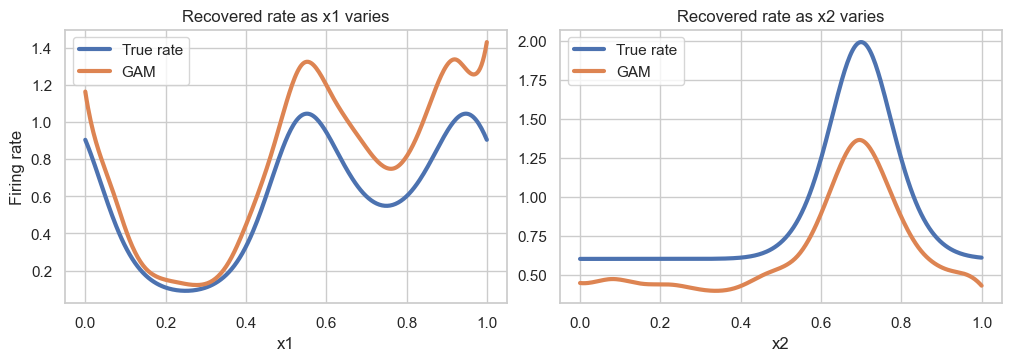

In [12]:
x2_ref = np.full_like(x_plot, 0.2)
x1_ref = np.full_like(x_plot, 0.8)

true_rate_x1 = np.exp(gen_mu(x_plot, x2_ref))
gam_rate_x1 = np.asarray(gam.predict((x_plot, x2_ref)))

true_rate_x2 = np.exp(gen_mu(x1_ref, x_plot))
gam_rate_x2 = np.asarray(gam.predict((x1_ref, x_plot)))

fig, ax = plt.subplots(figsize=(10, 3.5), ncols=2, constrained_layout=True)

ax[0].plot(x_plot, true_rate_x1, label="True rate", linewidth=3)
ax[0].plot(x_plot, gam_rate_x1, label="GAM", linewidth=3)
ax[0].set(xlabel="x1", ylabel="Firing rate", title="Recovered rate as x1 varies")

ax[1].plot(x_plot, true_rate_x2, label="True rate", linewidth=3)
ax[1].plot(x_plot, gam_rate_x2, label="GAM", linewidth=3)
ax[1].set(xlabel="x2", title="Recovered rate as x2 varies")

for axi in ax:
    axi.legend()

The rate as a function of both variables:

In [13]:
gam_rate_surface = np.asarray(gam.predict((x1_surface.ravel(), x2_surface.ravel()))).reshape(x1_surface.shape)

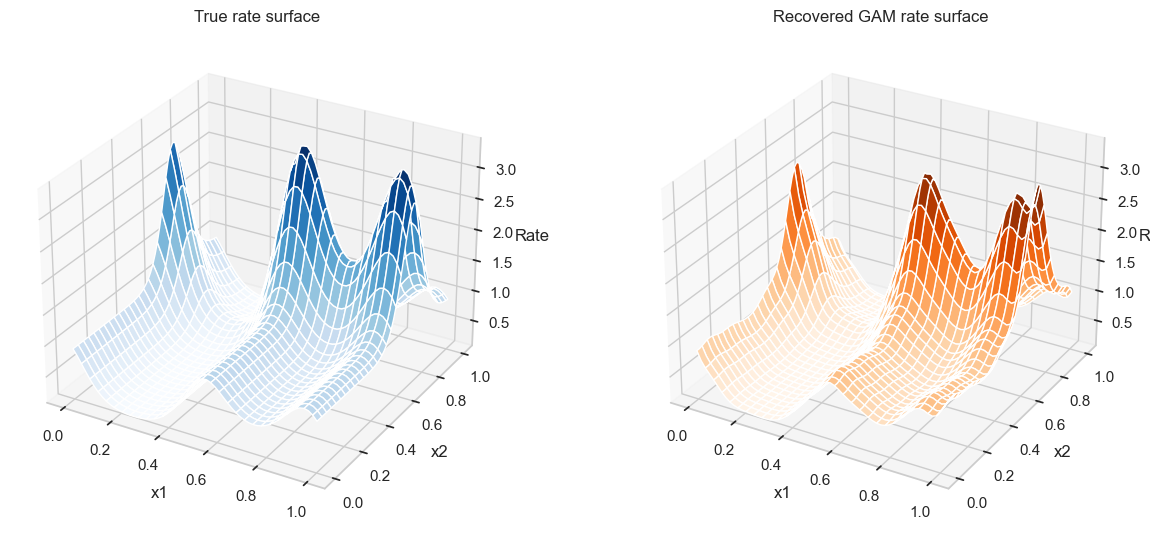

In [14]:
z_min = min(true_rate_surface.min(), gam_rate_surface.min())
z_max = max(true_rate_surface.max(), gam_rate_surface.max())

fig = plt.figure(figsize=(13, 5.5))
ax_true = fig.add_subplot(1, 2, 1, projection="3d")
ax_gam = fig.add_subplot(1, 2, 2, projection="3d")

ax_true.plot_surface(x1_surface, x2_surface, true_rate_surface, cmap="Blues")
ax_true.set_title("True rate surface")
ax_true.set_xlabel("x1")
ax_true.set_ylabel("x2")
ax_true.set_zlabel("Rate")
ax_true.set_zlim(z_min, z_max)
ax_true.view_init(elev=28, azim=-60)

ax_gam.plot_surface(x1_surface, x2_surface, gam_rate_surface, cmap="Oranges")
ax_gam.set_title("Recovered GAM rate surface")
ax_gam.set_xlabel("x1")
ax_gam.set_ylabel("x2")
ax_gam.set_zlabel("Rate")
ax_gam.set_zlim(z_min, z_max)
ax_gam.view_init(elev=28, azim=-60)

fig.tight_layout()

In the same interactive plot:

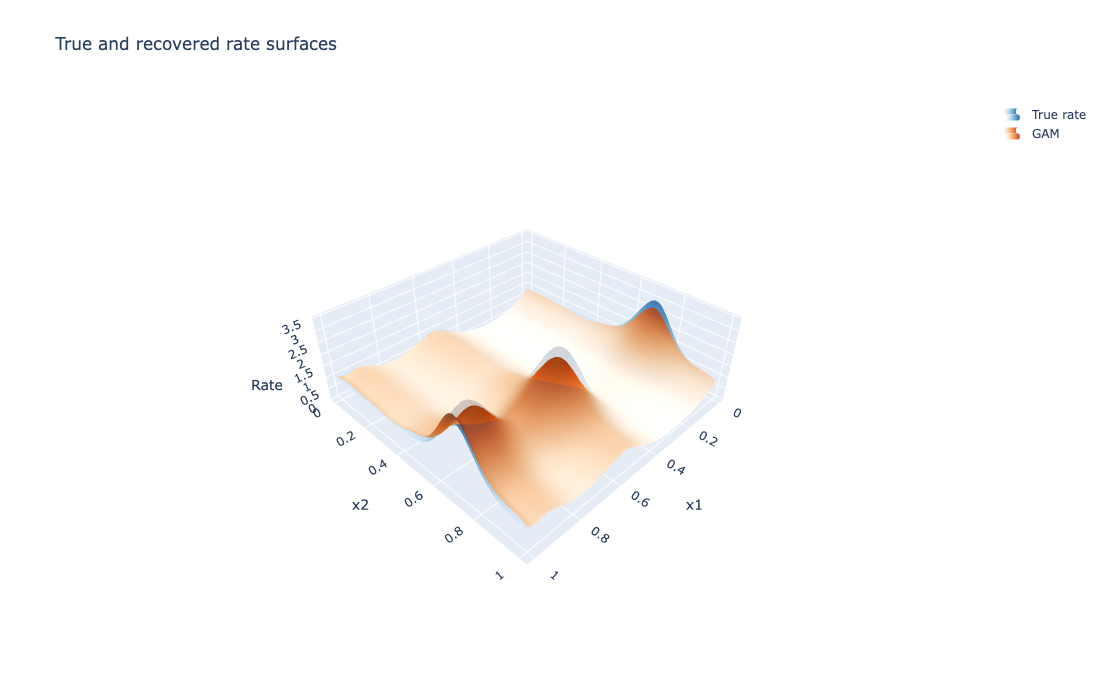

In [15]:
fig = go.Figure()

fig.add_surface(
    x=x1_surface,
    y=x2_surface,
    z=true_rate_surface,
    colorscale="Blues",
    opacity=0.75,
    name="True rate",
    showscale=False,
    showlegend=True,
)
fig.add_surface(
    x=x1_surface,
    y=x2_surface,
    z=gam_rate_surface,
    colorscale="Oranges",
    opacity=0.75,
    name="GAM",
    showscale=False,
    showlegend=True,
)

fig.update_layout(
    title="True and recovered rate surfaces",
    scene=dict(
        xaxis_title="x1",
        yaxis_title="x2",
        zaxis_title="Rate",
        aspectmode="manual",
        aspectratio=dict(x=1, y=1, z=0.35),
    ),
    width=900,
    height=700,
)

fig.show()